In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%pip install fast-langdetect

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 789.9/789.9 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.1/296.1 kB 14.8 MB/s eta 0:00:00


In [ ]:
from fast_langdetect import detect_language, detect

example2 = detect("Hello 世界 こんにちは")

print(example2)

[2026-04-21 13:55:53,088][INFO] - Downloading https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin to lid.176.bin (125.2M)
INFO:robust_downloader.downloader:Downloading https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin to lid.176.bin (125.2M)


  0%|          | 0.00/125M [00:00<?, ?B/s]

[{'lang': 'ja', 'score': 0.9975278973579407}]


In [4]:
from fast_langdetect import detect

def clean_phomt_test_set(df):
    """
    Identifies rows where the Vietnamese ground truth is actually English.
    """
    def is_pass_through(text):
        if not isinstance(text, str) or len(text.strip()) < 5:
            return False

        result = detect(text)

        if (len(result) == 1) and (result[0]['lang'] == 'en'):
            return False
        else:
            return True

    # Apply the check to the Vietnamese column
    df['is_vietnamese'] = df['Ground_Truth'].apply(is_pass_through)

    # Filter the dataframe
    clean_df = df[~df['is_vietnamese']].copy()

    return clean_df

# Ground Truth

In [16]:
results_ground_truth = pd.read_csv('/content/results_PhoMT_ground_truth.csv')
results_ground_truth.drop(columns=['Model_Translation'], inplace=True)

In [17]:
results_ground_truth_not_clean = clean_phomt_test_set(results_ground_truth)
results_ground_truth_not_clean.shape

(20, 4)

In [18]:
results_ground_truth = results_ground_truth[results_ground_truth['is_vietnamese']]
results_ground_truth.shape

(19131, 4)

In [19]:
# Get descriptive statistics for the COMET-22 score
comet_stats = results_ground_truth['COMET_Kiwi'].describe()
print("COMET-Kiwi Score Statistics:")
print(comet_stats)

COMET-Kiwi Score Statistics:
count    19131.000000
mean         0.808595
std          0.085022
min          0.302361
25%          0.782196
50%          0.839373
75%          0.864790
max          0.905758
Name: COMET_Kiwi, dtype: float64


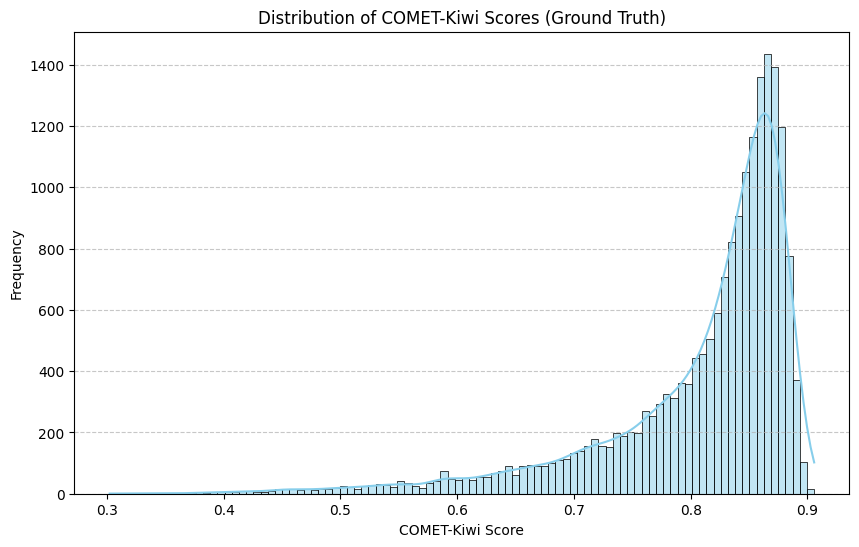

In [20]:
# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(results_ground_truth['COMET_Kiwi'], kde=True, color='skyblue')
plt.title('Distribution of COMET-Kiwi Scores (Ground Truth)')
plt.xlabel('COMET-Kiwi Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

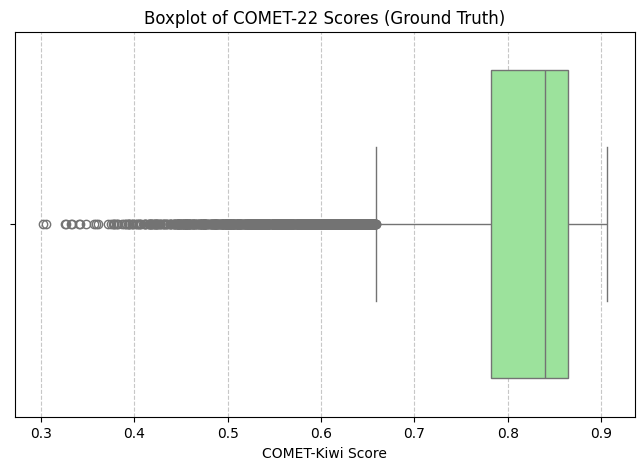

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=results_ground_truth['COMET_Kiwi'], color='lightgreen')
plt.title('Boxplot of COMET-22 Scores (Ground Truth)')
plt.xlabel('COMET-Kiwi Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [22]:
results_ground_truth[results_ground_truth['COMET_Kiwi'] > 0.8].shape

(13370, 4)

# Qwen3.5-0.8B

In [ ]:
results_qwen3_5_0_8b = pd.read_csv('/content/results_PhoMT_qwen3.5-0.8b.csv')

In [ ]:
results_qwen3_5_0_8b_not_clean = clean_phomt_test_set(results_qwen3_5_0_8b)
results_qwen3_5_0_8b_not_clean.shape

(20, 5)

In [ ]:
results_qwen3_5_0_8b = results_qwen3_5_0_8b[results_qwen3_5_0_8b['is_vietnamese']]
results_qwen3_5_0_8b.shape

(19131, 5)

In [ ]:
# Get descriptive statistics for the COMET-22 score
comet_stats = results_qwen3_5_0_8b['COMET_Kiwi'].describe()
print("COMET-Kiwi Score Statistics:")
print(comet_stats)

COMET-Kiwi Score Statistics:
count    19131.000000
mean         0.766782
std          0.112101
min          0.186311
25%          0.710073
50%          0.804122
75%          0.853227
max          0.905940
Name: COMET_Kiwi, dtype: float64


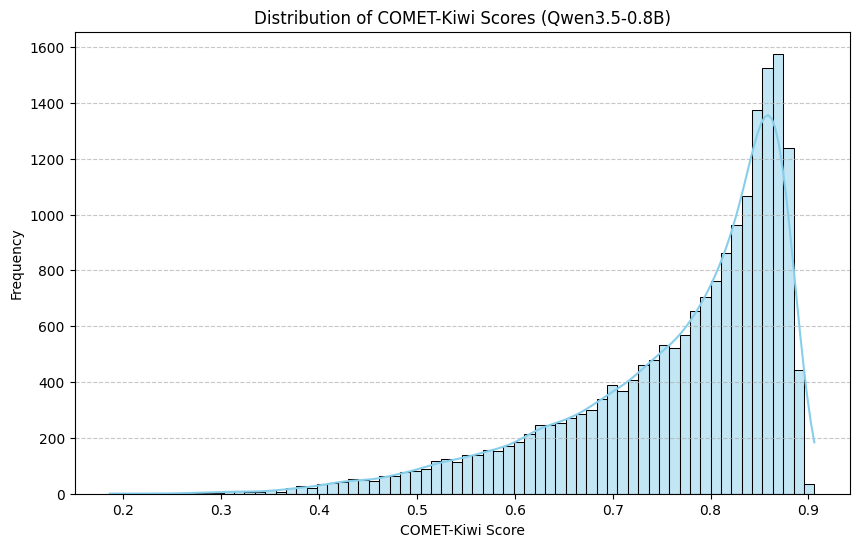

In [ ]:
# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(results_qwen3_5_0_8b['COMET_Kiwi'], kde=True, color='skyblue')
plt.title('Distribution of COMET-Kiwi Scores (Qwen3.5-0.8B)')
plt.xlabel('COMET-Kiwi Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

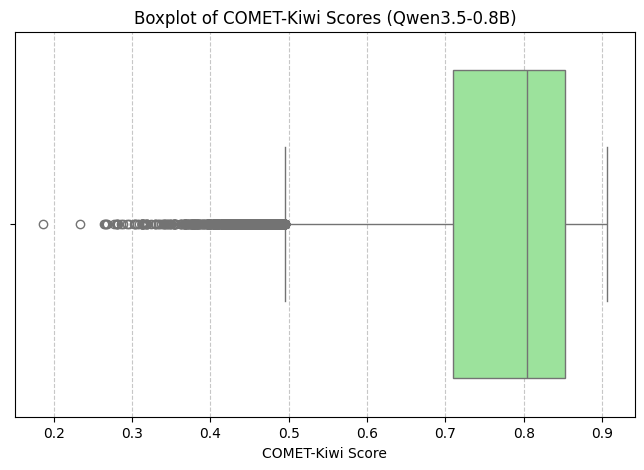

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=results_qwen3_5_0_8b['COMET_Kiwi'], color='lightgreen')
plt.title('Boxplot of COMET-Kiwi Scores (Qwen3.5-0.8B)')
plt.xlabel('COMET-Kiwi Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

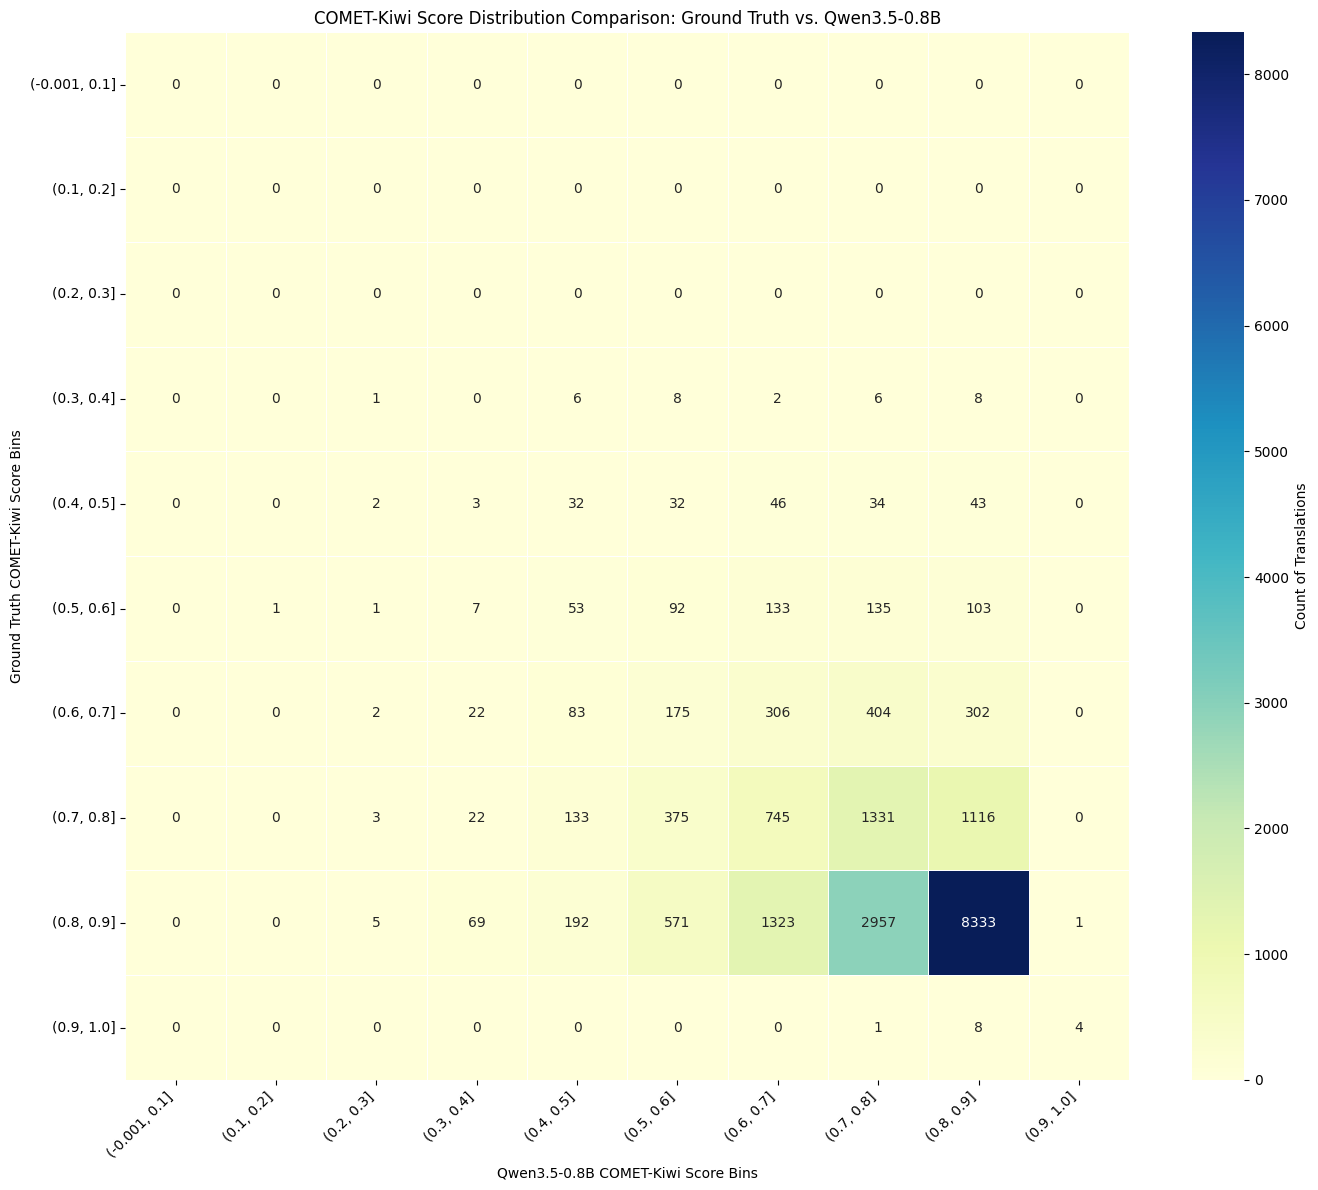

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

gt_scores_df = results_ground_truth[['English', 'Ground_Truth', 'COMET_Kiwi']].rename(columns={'COMET_Kiwi': 'COMET_Kiwi_GT'})
qwen_scores_df = results_qwen3_5_0_8b[['English', 'Model_Translation', 'COMET_Kiwi']].rename(columns={'COMET_Kiwi': 'COMET_Kiwi_Qwen'})

# Merge the two dataframes on the 'English' column to ensure we compare scores for the same source sentences.
# Use an inner merge to only keep sentences present in both cleaned datasets.
comparison_df = pd.merge(gt_scores_df, qwen_scores_df, on='English', how='inner')

if comparison_df.empty:
    print("No common sentences found after cleaning and merging. Cannot create comparison matrix.")
else:
    # 4. Define the bins for COMET-Kiwi scores
    # Scores typically range from 0 to 1. Let's create bins from 0.0 to 1.0 with a step of 0.1.
    bins = np.arange(0.0, 1.01, 0.1) # Creates edges: [0.0, 0.1, ..., 1.0]

    # 5. Discretize the scores into bins
    # pd.cut with right=True means (a, b], include_lowest=True means the first bin is [min_score, bin_0].
    # This setup creates interval labels like [0.0, 0.1], (0.1, 0.2], ..., (0.9, 1.0].
    comparison_df['COMET_Kiwi_GT_Bin'] = pd.cut(comparison_df['COMET_Kiwi_GT'], bins=bins, include_lowest=True, right=True)
    comparison_df['COMET_Kiwi_Qwen_Bin'] = pd.cut(comparison_df['COMET_Kiwi_Qwen'], bins=bins, include_lowest=True, right=True)

    # 6. Create and Visualize the "Confusion Matrix"
    # Create the confusion matrix-like heatmap data using crosstab.
    confusion_matrix_data = pd.crosstab(
        comparison_df['COMET_Kiwi_GT_Bin'],
        comparison_df['COMET_Kiwi_Qwen_Bin'],
        dropna=False # Keep all defined bins even if they have no entries for better visualization.
    )

    # Ensure the order of bins is correct on the plot axes.
    # The categories of the pd.IntervalIndex from pd.cut are naturally ordered.
    ordered_bins = comparison_df['COMET_Kiwi_GT_Bin'].cat.categories
    confusion_matrix_data = confusion_matrix_data.reindex(index=ordered_bins, columns=ordered_bins, fill_value=0)

    # Plot the heatmap
    plt.figure(figsize=(14, 12)) # Adjusted figure size for better readability.
    sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Count of Translations'})
    plt.title('COMET-Kiwi Score Distribution Comparison: Ground Truth vs. Qwen3.5-0.8B')
    plt.xlabel('Qwen3.5-0.8B COMET-Kiwi Score Bins')
    plt.ylabel('Ground Truth COMET-Kiwi Score Bins')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability.
    plt.yticks(rotation=0)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping.
    plt.show()

In [ ]:
# Define the specific bins for filtering
gt_bin_lower = 0.8
gt_bin_upper = 0.9
qwen_bin_lower = 0.4
qwen_bin_upper = 0.5

# Create Interval objects for filtering, matching how pd.cut generates them
gt_interval = pd.Interval(left=gt_bin_lower, right=gt_bin_upper, closed='right')
qwen_interval = pd.Interval(left=qwen_bin_lower, right=qwen_bin_upper, closed='right')

# Filter the comparison_df for the specified bins
samples_in_bin = comparison_df[
    (comparison_df['COMET_Kiwi_GT_Bin'] == gt_interval) &
    (comparison_df['COMET_Kiwi_Qwen_Bin'] == qwen_interval)
]

print(f"Found {len(samples_in_bin)} samples where Ground Truth COMET-Kiwi is in {gt_interval} and Qwen3.5-0.8B COMET-Kiwi is in {qwen_interval}:\n")

# Display the relevant columns for these samples, including Ground Truth and Model Translation
# Limiting to first 20 samples if there are many to avoid overwhelming output
display(samples_in_bin[['English', 'Ground_Truth', 'Model_Translation', 'COMET_Kiwi_GT', 'COMET_Kiwi_Qwen']].head(20))

Found 192 samples where Ground Truth COMET-Kiwi is in (0.8, 0.9] and Qwen3.5-0.8B COMET-Kiwi is in (0.4, 0.5]:



,English,Ground_Truth,Model_Translation,COMET_Kiwi_GT,COMET_Kiwi_Qwen
81,Accidents have been caused by the tollgates as...,Nhiều vụ tai nạn xảy ra do các trạm thu phí nà...,Các tai nạn đã xảy ra do các cổng thông báo.\n,0.802957,0.427487
542,More than you might think.,Nhiều hơn những gì bạn nghĩ đấy.,Không phải bạn nghĩ ra.\n,0.869839,0.473911
841,"or ""What's this Num Lock key for?""","hay ""Nút Num Lock này dùng để làm gì?""","""Không nghĩ đến phím số đếm không?""\n",0.859399,0.425942
1452,A fish ca n't do anything to a crow.,Còn một con cá chẳng thể làm gì nổi một con qu...,Không có gì làm gì cho một con chim.\n,0.814543,0.421380
1623,We agree that you ca n't flap your arms and fly.,Chúng ta nhất trí rằng bạn không thể vỗ cánh v...,Chúng tôi đồng ý rằng bạn không được bay cánh ...,0.835797,0.490231
1638,"At the end of Orwell's ""1984,"" the thought pol...","Vào phần cuối cuốn ""1984"" của Orwell, người đư...","Tại kết thúc của ""1984"" của Orwell, nhân viên ...",0.818723,0.491223
1863,"For myself, I tried to get away from infectiou...","Bản thân tôi, tôi đã cố lánh xa những dịch bện...",Tôi không nghĩ đến việc tránh khỏi các bệnh nh...,0.845223,0.490401
2291,And who did this drawing of you?,Vậy ai đã vẽ bức này cho bà?,Bạn vẽ gì đó này?\n,0.830580,0.437894
2389,"Would you get Ms. Winters a sparkling water, p...",Anh có thể lấy cho bà Winter một chai nước có ...,"Mô tả: ""Ms. Winters"" là một tên riêng, nên khô...",0.860260,0.437252
2436,- You ca n't make me!,- Anh không thể bắt tôi làm vậy!,- Không thể làm cho tôi!\n,0.849334,0.486217


# Qwen3.5-0.8B LoRA fine-tuned

In [5]:
results_qwen3_5_0_8b_lora_finetuned = pd.read_csv('/content/results_PhoMT_qwen3.5-0.8b_lora_fine_tuning.csv')

In [7]:
results_qwen3_5_0_8b_lora_finetuned_not_clean = clean_phomt_test_set(results_qwen3_5_0_8b_lora_finetuned)
results_qwen3_5_0_8b_lora_finetuned_not_clean.shape

[2026-04-29 03:30:28,898][INFO] - Downloading https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin to lid.176.bin (125.2M)
INFO:robust_downloader.downloader:Downloading https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin to lid.176.bin (125.2M)


  0%|          | 0.00/125M [00:00<?, ?B/s]

(20, 5)

In [9]:
results_qwen3_5_0_8b_lora_finetuned = results_qwen3_5_0_8b_lora_finetuned[results_qwen3_5_0_8b_lora_finetuned['is_vietnamese']]
results_qwen3_5_0_8b_lora_finetuned.shape

(19131, 5)

In [10]:
# Get descriptive statistics for the COMET-22 score
comet_stats = results_qwen3_5_0_8b_lora_finetuned['COMET_Kiwi'].describe()
print("COMET-Kiwi Score Statistics:")
print(comet_stats)

COMET-Kiwi Score Statistics:
count    19131.000000
mean         0.805310
std          0.086510
min          0.223404
25%          0.772191
50%          0.837095
75%          0.866434
max          0.906327
Name: COMET_Kiwi, dtype: float64


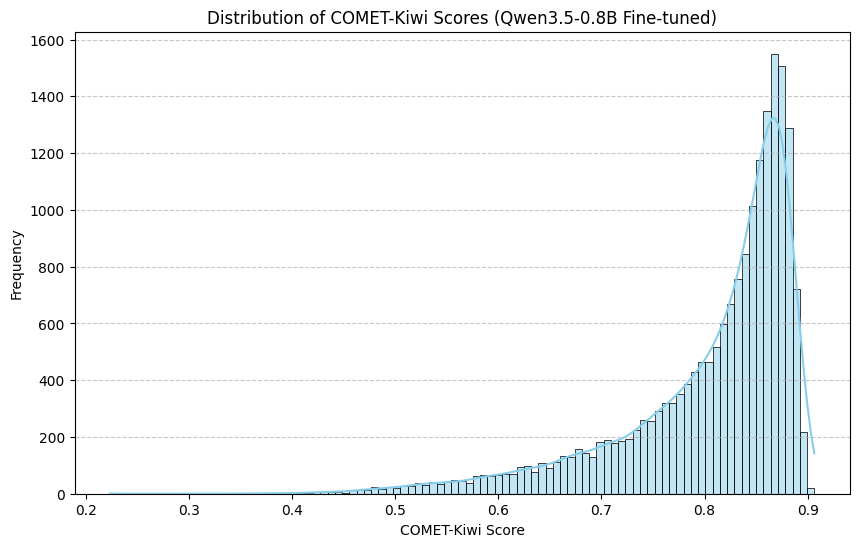

In [11]:
# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(results_qwen3_5_0_8b_lora_finetuned['COMET_Kiwi'], kde=True, color='skyblue')
plt.title('Distribution of COMET-Kiwi Scores (Qwen3.5-0.8B Fine-tuned)')
plt.xlabel('COMET-Kiwi Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

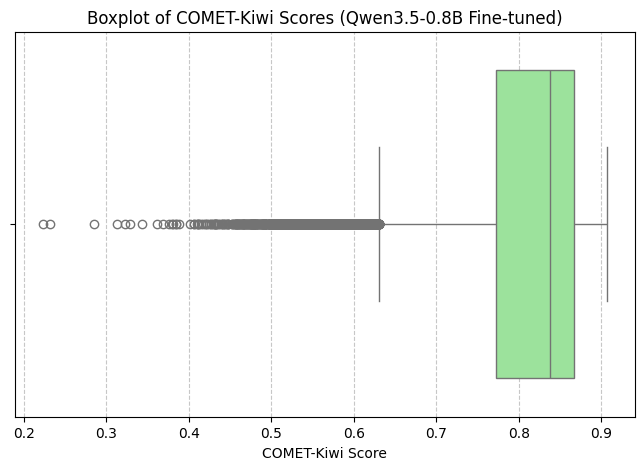

In [12]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=results_qwen3_5_0_8b_lora_finetuned['COMET_Kiwi'], color='lightgreen')
plt.title('Boxplot of COMET-Kiwi Scores (Qwen3.5-0.8B Fine-tuned)')
plt.xlabel('COMET-Kiwi Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

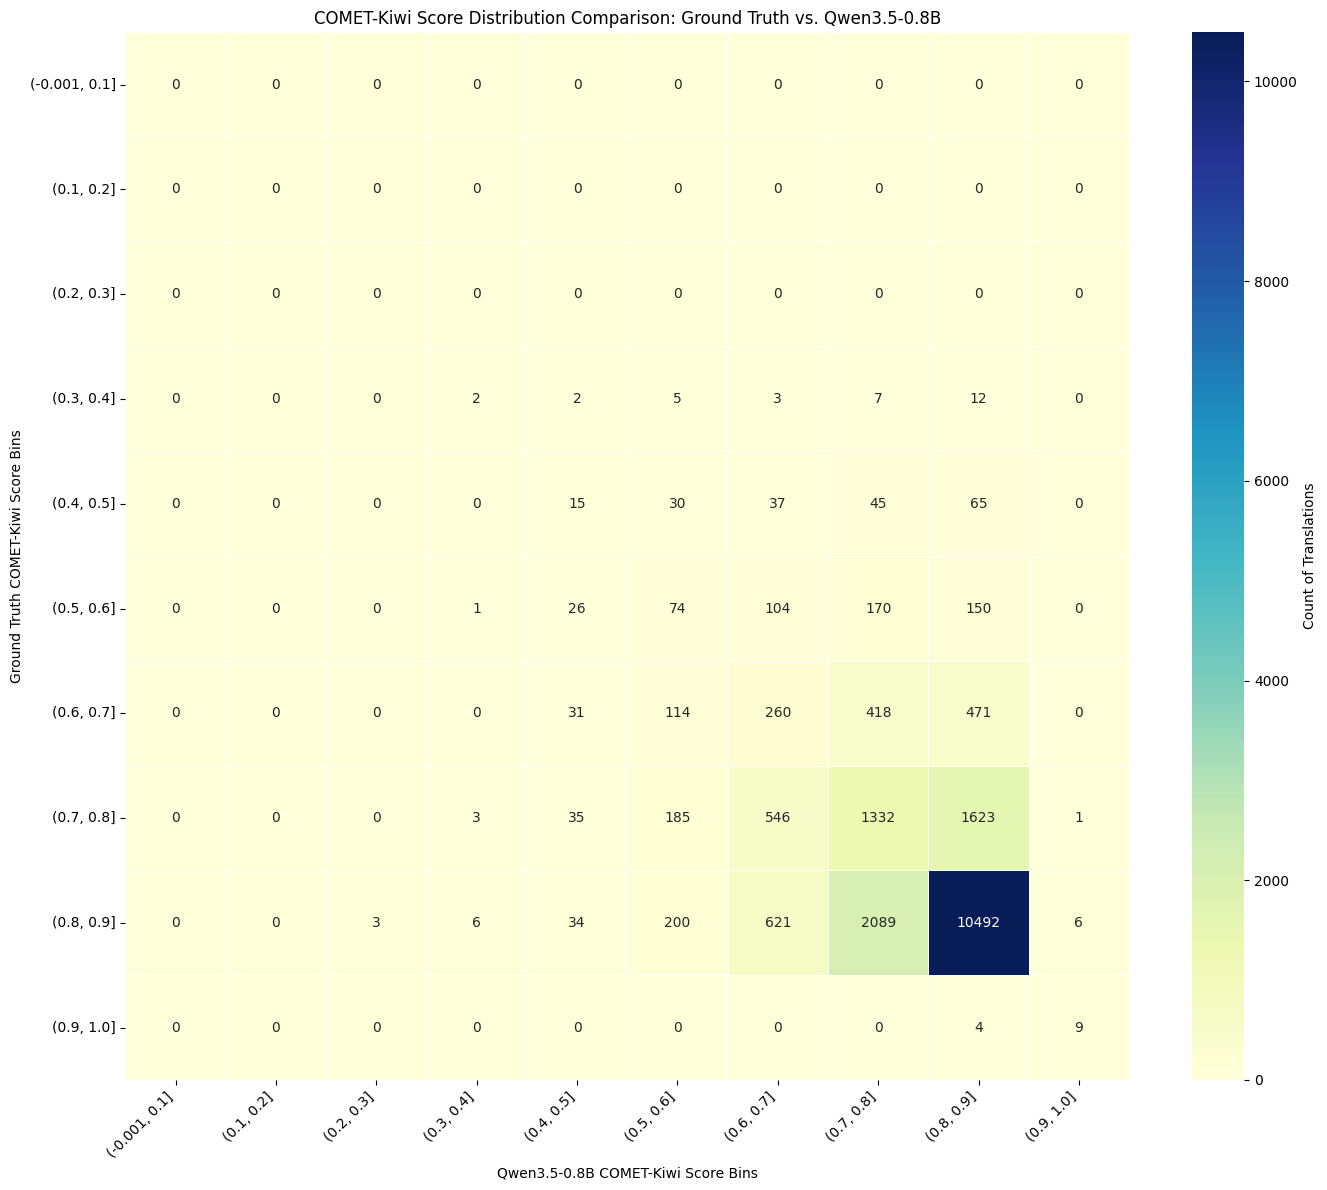

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

gt_scores_df = results_ground_truth[['English', 'Ground_Truth', 'COMET_Kiwi']].rename(columns={'COMET_Kiwi': 'COMET_Kiwi_GT'})
qwen_scores_df = results_qwen3_5_0_8b_lora_finetuned[['English', 'Model_Translation', 'COMET_Kiwi']].rename(columns={'COMET_Kiwi': 'COMET_Kiwi_Qwen'})

# Merge the two dataframes on the 'English' column to ensure we compare scores for the same source sentences.
# Use an inner merge to only keep sentences present in both cleaned datasets.
comparison_df = pd.merge(gt_scores_df, qwen_scores_df, on='English', how='inner')

if comparison_df.empty:
    print("No common sentences found after cleaning and merging. Cannot create comparison matrix.")
else:
    # 4. Define the bins for COMET-Kiwi scores
    # Scores typically range from 0 to 1. Let's create bins from 0.0 to 1.0 with a step of 0.1.
    bins = np.arange(0.0, 1.01, 0.1) # Creates edges: [0.0, 0.1, ..., 1.0]

    # 5. Discretize the scores into bins
    # pd.cut with right=True means (a, b], include_lowest=True means the first bin is [min_score, bin_0].
    # This setup creates interval labels like [0.0, 0.1], (0.1, 0.2], ..., (0.9, 1.0].
    comparison_df['COMET_Kiwi_GT_Bin'] = pd.cut(comparison_df['COMET_Kiwi_GT'], bins=bins, include_lowest=True, right=True)
    comparison_df['COMET_Kiwi_Qwen_Bin'] = pd.cut(comparison_df['COMET_Kiwi_Qwen'], bins=bins, include_lowest=True, right=True)

    # 6. Create and Visualize the "Confusion Matrix"
    # Create the confusion matrix-like heatmap data using crosstab.
    confusion_matrix_data = pd.crosstab(
        comparison_df['COMET_Kiwi_GT_Bin'],
        comparison_df['COMET_Kiwi_Qwen_Bin'],
        dropna=False # Keep all defined bins even if they have no entries for better visualization.
    )

    # Ensure the order of bins is correct on the plot axes.
    # The categories of the pd.IntervalIndex from pd.cut are naturally ordered.
    ordered_bins = comparison_df['COMET_Kiwi_GT_Bin'].cat.categories
    confusion_matrix_data = confusion_matrix_data.reindex(index=ordered_bins, columns=ordered_bins, fill_value=0)

    # Plot the heatmap
    plt.figure(figsize=(14, 12)) # Adjusted figure size for better readability.
    sns.heatmap(confusion_matrix_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Count of Translations'})
    plt.title('COMET-Kiwi Score Distribution Comparison: Ground Truth vs. Qwen3.5-0.8B')
    plt.xlabel('Qwen3.5-0.8B COMET-Kiwi Score Bins')
    plt.ylabel('Ground Truth COMET-Kiwi Score Bins')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability.
    plt.yticks(rotation=0)
    plt.tight_layout() # Adjust layout to prevent labels from overlapping.
    plt.show()

In [24]:
# Define the specific bins for filtering
gt_bin_lower = 0.8
gt_bin_upper = 0.9
qwen_bin_lower = 0.4
qwen_bin_upper = 0.5

# Create Interval objects for filtering, matching how pd.cut generates them
gt_interval = pd.Interval(left=gt_bin_lower, right=gt_bin_upper, closed='right')
qwen_interval = pd.Interval(left=qwen_bin_lower, right=qwen_bin_upper, closed='right')

# Filter the comparison_df for the specified bins
samples_in_bin = comparison_df[
    (comparison_df['COMET_Kiwi_GT_Bin'] == gt_interval) &
    (comparison_df['COMET_Kiwi_Qwen_Bin'] == qwen_interval)
]

print(f"Found {len(samples_in_bin)} samples where Ground Truth COMET-Kiwi is in {gt_interval} and Qwen3.5-0.8B COMET-Kiwi is in {qwen_interval}:\n")

# Display the relevant columns for these samples, including Ground Truth and Model Translation
# Limiting to first 20 samples if there are many to avoid overwhelming output
display(samples_in_bin[['English', 'Ground_Truth', 'Model_Translation', 'COMET_Kiwi_GT', 'COMET_Kiwi_Qwen']].head(20))

Found 34 samples where Ground Truth COMET-Kiwi is in (0.8, 0.9] and Qwen3.5-0.8B COMET-Kiwi is in (0.4, 0.5]:



,English,Ground_Truth,Model_Translation,COMET_Kiwi_GT,COMET_Kiwi_Qwen
1452,A fish ca n't do anything to a crow.,Còn một con cá chẳng thể làm gì nổi một con qu...,Một con cá không thể làm gì cho một con huy.,0.814543,0.498881
1861,So I did n't mean to come up with this at all.,Vậy nên tôi không muốn đưa ra ý tưởng này chút...,Vậy tôi không muốn nói chuyện này là do tôi tự...,0.833714,0.455263
2329,I like to do my own eyebrows.,Tôi thích tự kẻ lông mày của mình.,Tôi thích làm mông mông của mình.,0.872212,0.441252
2840,"Shut it, shut it down. Shut it down.","Đóng nó lại, đóng nó lại đi.","Đừng nghĩ, hãy đóng nó, đóng nó.",0.841938,0.492888
2876,Your pupils are dilated.,Đồng tử của chú mày đang giãn ra.,Cậu học sinh bị giãn mạch.,0.808179,0.492550
2893,"Come on, man.",Cố lên đi nào anh bạn.,"Đừng bao giờ nghĩ, anh.",0.855152,0.483990
3622,"High class, good reputation.","Tầng lớp thượng lưu, có danh tiếng.","Của riêng, có uy tín.",0.817657,0.478704
3628,"I know, you wanna pee.",Tôi biết cô muốn đi tiểu.,"Tôi biết, anh muốn ur.",0.877046,0.489590
3680,Pretty nice car for a cook.,Một chiếc xe đẹp cho một đầu bếp.,Đàn xe này rất đẹp cho một người làm ăn.,0.864056,0.460243
3693,Come back any time.,Ông có thể quay lại bất cứ lúc nào.,Đừng bao giờ bỏ lỡ.,0.866650,0.466280


# Qwen3.5-2B

In [ ]:
results_qwen3_5_2b = pd.read_csv('/content/results_PhoMT_qwen3.5-2b.csv')

In [ ]:
# Get descriptive statistics for the COMET-22 score
comet_stats = results_qwen3_5_2b['COMET_Kiwi'].describe()
print("COMET-Kiwi Score Statistics:")
print(comet_stats)

COMET-Kiwi Score Statistics:
count    19151.000000
mean         0.819712
std          0.075529
min          0.211973
25%          0.799175
50%          0.846755
75%          0.868366
max          0.906605
Name: COMET_Kiwi, dtype: float64


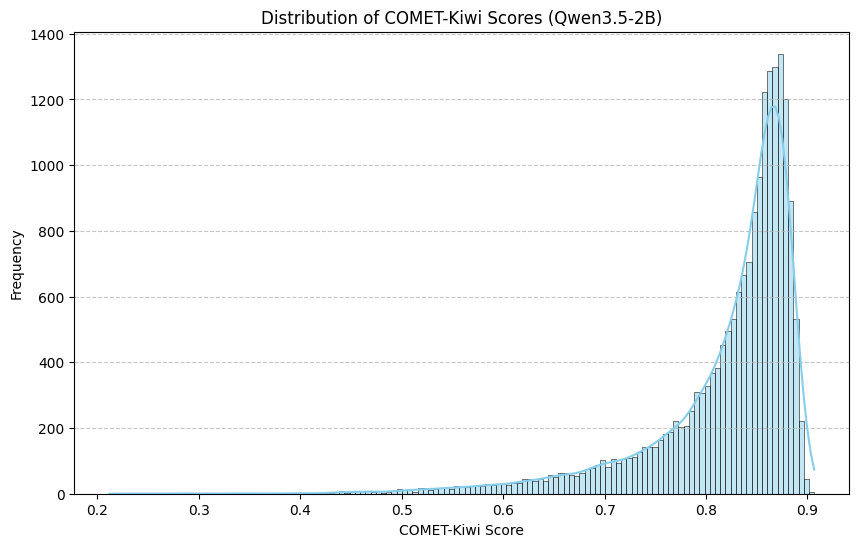

In [ ]:
# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(results_qwen3_5_2b['COMET_Kiwi'], kde=True, color='skyblue')
plt.title('Distribution of COMET-Kiwi Scores (Qwen3.5-2B)')
plt.xlabel('COMET-Kiwi Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

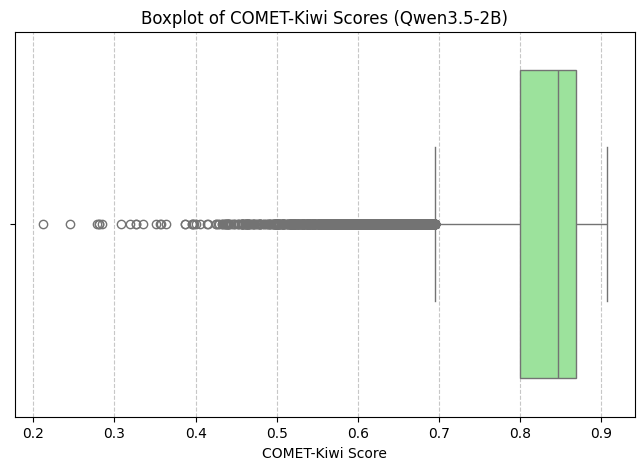

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=results_qwen3_5_2b['COMET_Kiwi'], color='lightgreen')
plt.title('Boxplot of COMET-Kiwi Scores (Qwen3.5-2B)')
plt.xlabel('COMET-Kiwi Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# TranslateGemma-4B-IT

In [ ]:
results_translategemma = pd.read_csv('/content/results_PhoMT_translategemma-4b-it.csv')

In [ ]:
# Get descriptive statistics for the COMET-22 score
comet_stats = results_translategemma['COMET_Kiwi'].describe()
print("COMET-Kiwi Score Statistics:")
print(comet_stats)

COMET-Kiwi Score Statistics:
count    19151.000000
mean         0.830489
std          0.070547
min          0.172128
25%          0.817841
50%          0.853980
75%          0.871480
max          0.906327
Name: COMET_Kiwi, dtype: float64


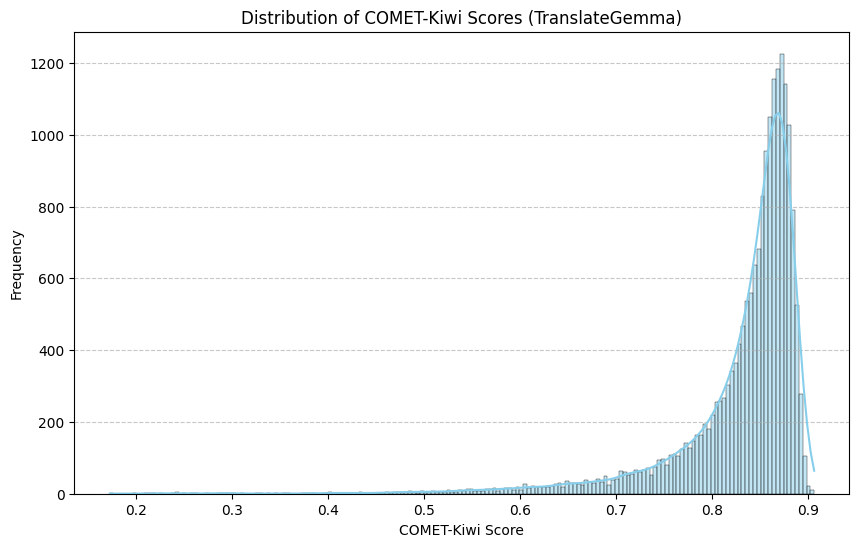

In [ ]:
# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(results_translategemma['COMET_Kiwi'], kde=True, color='skyblue')
plt.title('Distribution of COMET-Kiwi Scores (TranslateGemma)')
plt.xlabel('COMET-Kiwi Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

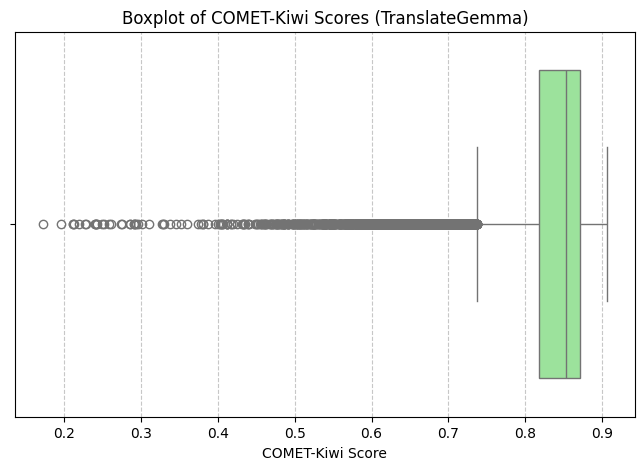

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=results_translategemma['COMET_Kiwi'], color='lightgreen')
plt.title('Boxplot of COMET-Kiwi Scores (TranslateGemma)')
plt.xlabel('COMET-Kiwi Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# VinAI Translate

In [ ]:
results_vinai_translate = pd.read_csv('/content/results_PhoMT_vinai_translate.csv')

In [ ]:
# Get descriptive statistics for the COMET-22 score
comet_stats = results_vinai_translate['COMET_Kiwi'].describe()
print("COMET-Kiwi Score Statistics:")
print(comet_stats)

COMET-Kiwi Score Statistics:
count    19151.000000
mean         0.835110
std          0.060245
min          0.364513
25%          0.821332
50%          0.855227
75%          0.872047
max          0.906177
Name: COMET_Kiwi, dtype: float64


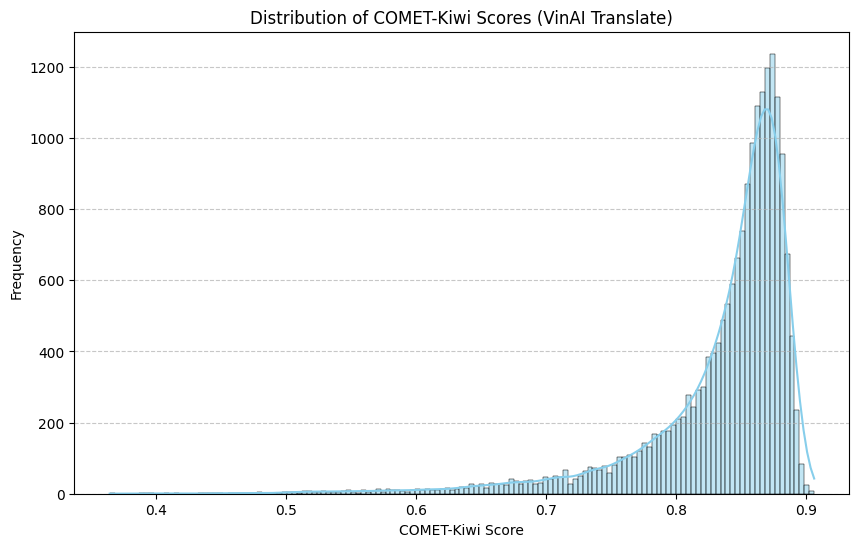

In [ ]:
# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(results_vinai_translate['COMET_Kiwi'], kde=True, color='skyblue')
plt.title('Distribution of COMET-Kiwi Scores (VinAI Translate)')
plt.xlabel('COMET-Kiwi Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

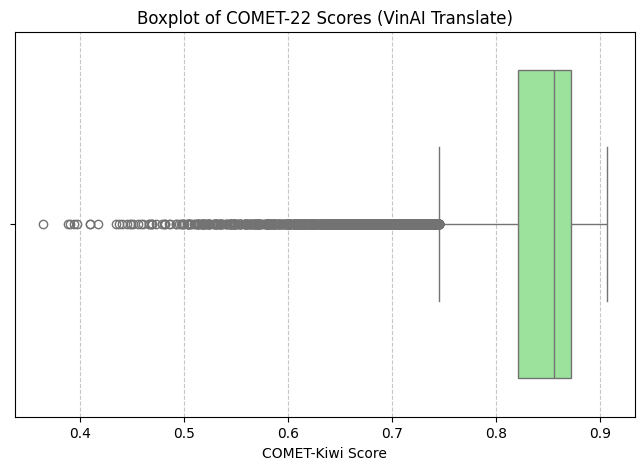

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=results_vinai_translate['COMET_Kiwi'], color='lightgreen')
plt.title('Boxplot of COMET-22 Scores (VinAI Translate)')
plt.xlabel('COMET-Kiwi Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Llama3.2-1B-IT

In [ ]:
results_llama3_2_1b_it = pd.read_csv('/content/results_PhoMT_llama3.2-1b-it.csv')

In [ ]:
# Get descriptive statistics for the COMET-22 score
comet_stats = results_llama3_2_1b_it['COMET_Kiwi'].describe()
print("COMET-Kiwi Score Statistics:")
print(comet_stats)

COMET-Kiwi Score Statistics:
count    19151.000000
mean         0.686298
std          0.155476
min          0.198914
25%          0.576940
50%          0.721555
75%          0.820116
max          0.904323
Name: COMET_Kiwi, dtype: float64


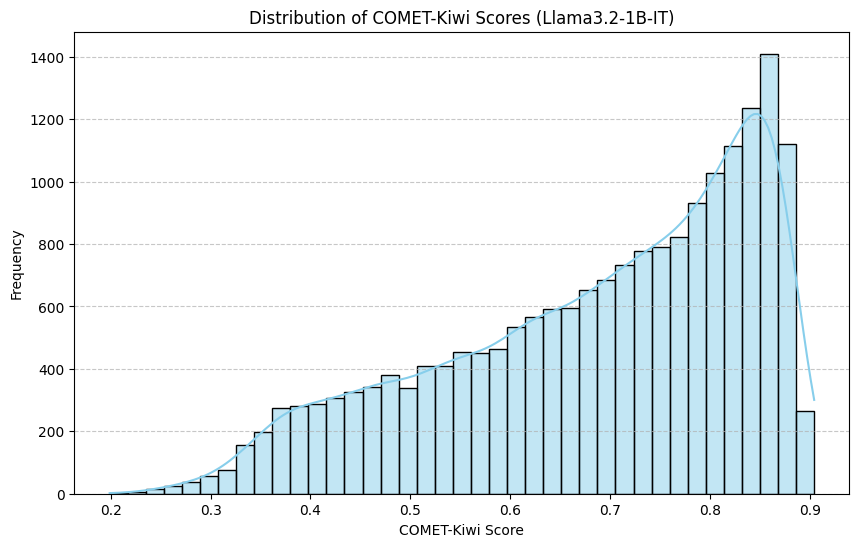

In [ ]:
# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.histplot(results_llama3_2_1b_it['COMET_Kiwi'], kde=True, color='skyblue')
plt.title('Distribution of COMET-Kiwi Scores (Llama3.2-1B-IT)')
plt.xlabel('COMET-Kiwi Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

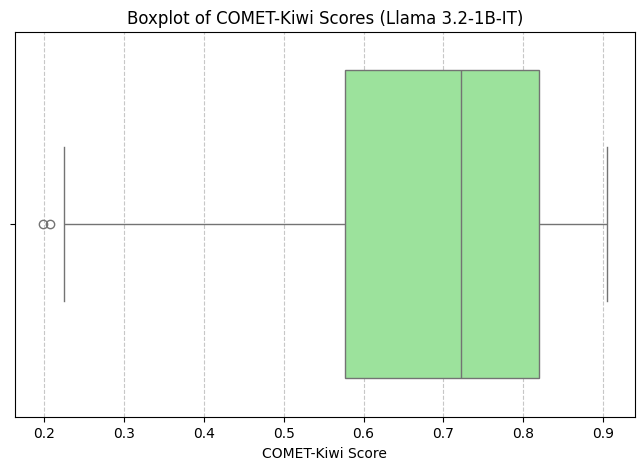

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=results_llama3_2_1b_it['COMET_Kiwi'], color='lightgreen')
plt.title('Boxplot of COMET-Kiwi Scores (Llama 3.2-1B-IT)')
plt.xlabel('COMET-Kiwi Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Find outlier

In [ ]:
def get_outliers(df, column='COMET_Kiwi'):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

In [ ]:
outliers_qwen3_5_0_8b = get_outliers(results_qwen3_5_0_8b)

In [ ]:
outliers_qwen3_5_0_8b.shape

(617, 4)

In [ ]:
outliers_qwen3_5_0_8b.to_csv('outliers_PhoMT_qwen3_5_0_8b_COMET-Kiwi.csv', index=False)
print("Outliers saved")

Outliers saved


In [ ]:
outliers_qwen3_5_2b = get_outliers(results_qwen3_5_2b)

In [ ]:
outliers_qwen3_5_2b.shape

(1447, 4)

In [ ]:
outliers_qwen3_5_2b.to_csv('outliers_PhoMT_qwen3_5_2b_COMET-Kiwi.csv', index=False)
print("Outliers saved")

Outliers saved


In [ ]:
outliers_ground_truth = get_outliers(results_ground_truth)

In [ ]:
outliers_ground_truth.shape

(1346, 4)

In [ ]:
outliers_ground_truth.to_csv('outliers_PhoMT_ground_truth_COMET-Kiwi.csv', index=False)
print("Outliers saved")

Outliers saved


In [ ]:
output_filename = 'qwen3_5_0_8b_outliers.txt'

with open(output_filename, 'w', encoding='utf-8') as f:
    for index, row in outliers_qwen3_5_0_8b.iterrows():
        f.write(f"--- Outlier {index} ---\n")
        f.write(f"English: {row['English']}\n")
        f.write(f"Ground Truth: {row['Ground_Truth']}\n")
        f.write(f"Model Translation: {row['Model_Translation']}\n")
        f.write(f"COMET-Kiwi Score: {row['COMET_Kiwi']}\n")
        f.write("\n")

print(f"Outlier details written to {output_filename}")

Outlier details written to qwen3_5_0_8b_outliers.txt
